In [3]:
#imports libraries and reads data
import pandas as pd
import numpy as np
import ast

df = pd.read_csv("data/movies_metadata.csv", low_memory=False)


In [5]:
#fixes the column types
for col in ["id", "budget", "revenue", "runtime"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

# A few rows in this file are malformed and have no valid ID
df = df.dropna(subset=["id"])
df = df.drop_duplicates(subset="id")
print(df.shape)

(44985, 24)


In [11]:
# Keep only movies where budget and revenue are actually known
# (0 means "unknown" in this dataset; tiny values are usually entry errors)
movies = df[(df["budget"] >= 10_000) & (df["revenue"] >= 10_000)].copy()


In [12]:
# calculates profitability
movies["profitability"] = movies["revenue"] - movies["budget"]

# 1 if the movie made a profit, 0 if not
movies["is_profitable"] = (movies["profitability"] > 0).astype(int)

print(movies.shape)
print(movies["is_profitable"].value_counts())

(5271, 26)
is_profitable
1    3715
0    1556
Name: count, dtype: int64


In [13]:
import ast

# Release timing
movies["release_year"] = movies["release_date"].dt.year
movies["release_month"] = movies["release_date"].dt.month

# Part of a franchise? (1 = yes, 0 = no)
movies["is_franchise"] = movies["belongs_to_collection"].notna().astype(int)

# English-language film? (1 = yes, 0 = no)
movies["is_english"] = (movies["original_language"] == "en").astype(int)

# Genres: one yes/no column per genre
def parse_names(text):
    try:
        return "|".join(item["name"] for item in ast.literal_eval(text))
    except (ValueError, SyntaxError, TypeError):
        return ""
genre_dummies = movies["genres"].apply(parse_names).str.get_dummies(sep="|")
movies = pd.concat([movies, genre_dummies], axis=1)

# Drop the few movies missing runtime or release date
movies.loc[movies["runtime"] <= 0, "runtime"] = np.nan
movies = movies.dropna(subset=["runtime", "release_year"])
print(movies.shape)

(5260, 50)


In [14]:
#defines a helper function for reading text in genres and production compaies
def parse_names(text):
    """Turn "[{'id': 18, 'name': 'Drama'}, ...]" into ['Drama', ...]"""
    try:
        return [item["name"] for item in ast.literal_eval(text)]
    except (ValueError, SyntaxError, TypeError):
        return []

In [15]:
#cleans up runtime and makes sure runtime is greater than 0
movies["runtime"] = pd.to_numeric(movies["runtime"], errors="coerce")
movies.loc[movies["runtime"] <= 0, "runtime"] = np.nan
print(movies["runtime"].isna().sum(), "movies missing runtime")

0 movies missing runtime


In [16]:
#converts release date to release year and release month
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["release_year"] = movies["release_date"].dt.year
movies["release_month"] = movies["release_date"].dt.month
movies[["release_date", "release_year", "release_month"]].head()

,release_date,release_year,release_month
0,1995-10-30,1995,10
1,1995-12-15,1995,12
3,1995-12-22,1995,12
5,1995-12-15,1995,12
8,1995-12-22,1995,12


In [ ]:
# is franchise? 1 yes 2 no
movies["is_franchise"] = movies["belongs_to_collection"].notna().astype(int)
print(movies["is_franchise"].value_counts())

is_franchise
0    4046
1    1214
Name: count, dtype: int64


In [18]:
# is english? 1 yes 2 no 
movies["is_english"] = (movies["original_language"] == "en").astype(int)
print(movies["is_english"].value_counts())

is_english
1    4709
0     551
Name: count, dtype: int64


In [19]:
#is major studio? 
major_keywords = ["Warner", "Universal", "Paramount", "Fox", "Columbia", "Sony", "Disney"]

movies["company_list"] = movies["production_companies"].apply(parse_names)
movies["is_major_studio"] = movies["company_list"].apply(
    lambda companies: int(any(k in c for c in companies for k in major_keywords)))

print(movies["is_major_studio"].value_counts())

is_major_studio
0    3129
1    2131
Name: count, dtype: int64


In [20]:
#one column per genre
movies["genre_list"] = movies["genres"].apply(parse_names)
genre_dummies = movies["genre_list"].str.join("|").str.get_dummies(sep="|")
movies = pd.concat([movies, genre_dummies], axis=1)

print(len(genre_dummies.columns), "genres:", list(genre_dummies.columns))

20 genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


In [21]:
# drop movies with missing values
movies = movies.dropna(subset=["runtime", "release_year"])
print(movies.shape)

check_cols = ["budget", "runtime", "release_year", "release_month",
              "is_franchise", "is_english", "is_major_studio"]
print(movies[check_cols].isna().sum())

(5260, 73)
budget             0
runtime            0
release_year       0
release_month      0
is_franchise       0
is_english         0
is_major_studio    0
dtype: int64


(5260, 53)


is_profitable
1    3709
0    1551
Name: count, dtype: int64
is_profitable
1    0.705
0    0.295
Name: proportion, dtype: float64


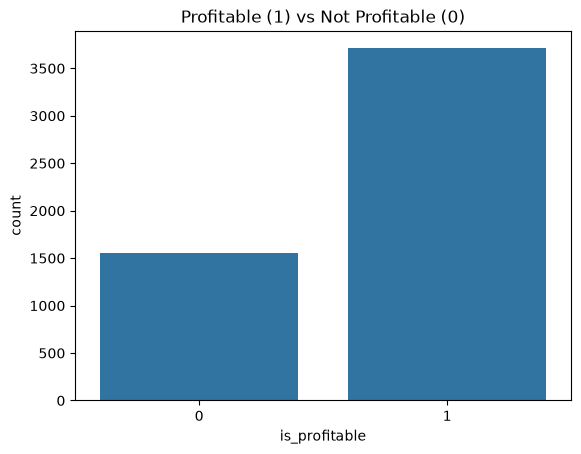

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print(movies["is_profitable"].value_counts())
print(movies["is_profitable"].value_counts(normalize=True).round(3))

sns.countplot(data=movies, x="is_profitable")
plt.title("Profitable (1) vs Not Profitable (0)")
plt.show()